In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()


In [54]:
df = pd.read_csv("fcc-forum-pageviews.csv").set_index('date')
df

,value
date,
2016-05-09,1201
2016-05-10,2329
2016-05-11,1716
2016-05-12,10539
2016-05-13,6933
...,...
2019-11-29,171584
2019-11-30,141161
2019-12-01,142918


In [55]:
df = df[((df['value'] > df['value'].quantile(0.025)) & (df['value'] < df['value'].quantile(0.975)))]
df

,value
date,
2016-05-19,19736
2016-05-26,18060
2016-05-27,19997
2016-05-28,19044
2016-05-29,20325
...,...
2019-11-24,138875
2019-11-29,171584
2019-11-30,141161


Text(0.5, 1.0, 'Daily freeCodeCamp Forum Page Views 5/2016-12/2019')

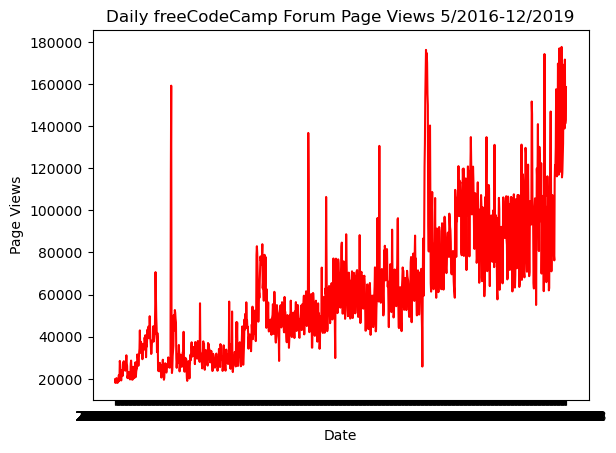

In [56]:
x_data = df.index
y_data = df['value']
fig = plt.plot(x_data,y_data,'r')
plt.ylabel('Page Views')
plt.xlabel('Date')
plt.title('Daily freeCodeCamp Forum Page Views 5/2016-12/2019')

In [57]:
df_bar = df.copy()


In [ ]:
df_bar.index = pd.to_datetime(df_bar.index)
df_bar['year'] = df_bar.index.year
df_bar['month'] = df_bar.index.month_name()
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 
'July', 'August', 'September', 'October', 'November', 'December']
df_bar['month'] = pd.Categorical(df_bar['month'],categories=months_order,ordered=True)

dataset = df_bar.groupby(['year','month'])['value'].mean().unstack()
dataset

C:\Users\agast\AppData\Local\Temp\ipykernel_28756\3112641319.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dataset = df_bar.groupby(['year','month'])['value'].mean().dropna().unstack()


month,January,February,March,April,May,June,July,August,September,October,November,December
year,,,,,,,,,,,,
2016,NaN,NaN,NaN,NaN,19432.400000,21875.105263,24109.678571,31049.193548,41476.866667,27398.322581,40448.633333,27832.419355
2017,32785.161290,31113.071429,29369.096774,30878.733333,34244.290323,43577.500000,65806.838710,47712.451613,47376.800000,47438.709677,57701.566667,48420.580645
2018,58580.096774,65679.000000,62693.774194,62350.833333,56562.870968,70117.000000,63591.064516,62831.612903,65941.733333,111378.142857,78688.333333,80047.483871
2019,102056.516129,105968.357143,91214.483871,89368.433333,91439.903226,90435.642857,97236.566667,102717.310345,97268.833333,122802.272727,143166.428571,150733.500000


<Axes: xlabel='year'>

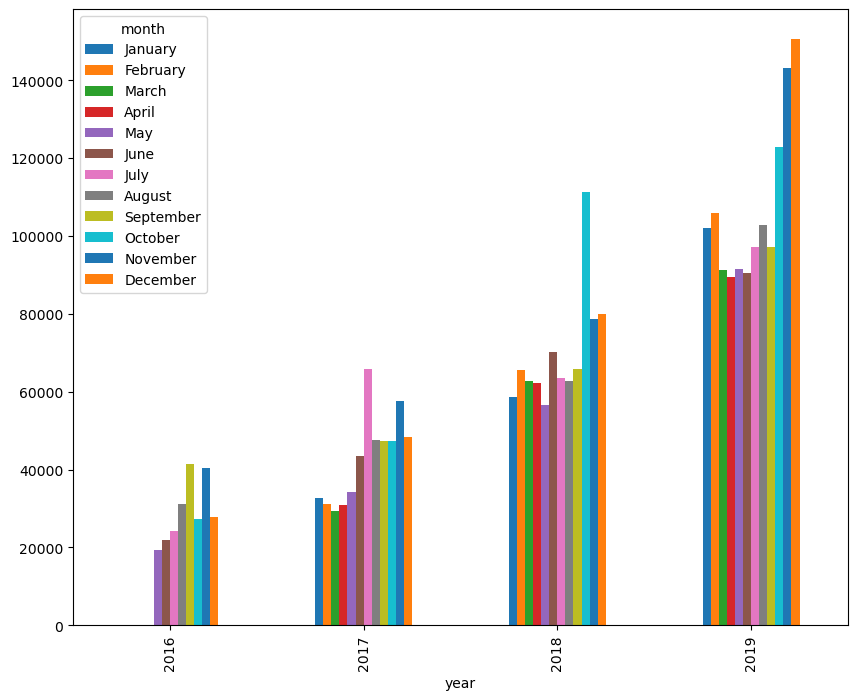

In [73]:
# 1. Initialize your Matplotlib canvas (adjust figsize as needed)
fig, ax = plt.subplots(figsize=(10, 8))

# 2. Tell Pandas to draw the bar chart on that specific 'ax' canvas
dataset.plot(kind='bar', ax=ax)

# 3. Add your labels and customize the legend here...